# Clustering des journées CO2 — OQAI CNL1

Objectif : identifier des **profils types de journées** à partir de la dynamique
du CO2 mesuré en continu dans les logements, puis relier ces profils aux
caractéristiques des occupants (structure du ménage, statut professionnel,
type de logement).

**Démarche :**
1. Chargement et préparation du signal CO2 (dérivée lissée)
2. Justification empirique de la normalisation retenue (4 échelles)
3. Clustering DTW des journées
4. Interprétation des clusters (profils, exemples, validation)
5. Caractérisation des clusters par le profil des occupants


## 1. Configuration et chargement


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from tslearn.clustering import TimeSeriesKMeans

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)

DATA = '../data/cln1/Raw'

# Lissage Savitzky-Golay : fenêtre de 13 points (10 min chacun ≈ 2h10) + polynôme d'ordre 2.
# Utilisé partout dans ce notebook, aussi bien pour la dérivée que pour les lissages simples.
SG_WINDOW = 13
SG_POLY   = 2

# Grille horaire commune : 144 tranches de 10 min → heures décimales (0 à 24)
hours = np.arange(144) / 6


In [ ]:
# Série CO2 continue (toutes les mesures, tous les logements)
co2 = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt',
                  sep='\t', encoding='latin1',
                  usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR'],
                  parse_dates=['DATE_HEURE'])
co2['VALEUR'] = pd.to_numeric(co2['VALEUR'], errors='coerce')
co2 = co2.dropna(subset=['VALEUR'])
co2['DATE'] = co2['DATE_HEURE'].dt.normalize()

print(f'{len(co2):,} mesures — {co2["CODELIEU"].nunique()} logements')
print(f'Période : {co2["DATE"].min().date()} → {co2["DATE"].max().date()}')


514,425 mesures — 535 logements
Période : 2003-10-01 → 2005-12-21


In [ ]:
# Référentiels : pièce du capteur, type de ventilation
pieces_ref = pd.read_csv(f'{DATA}/Identite_Logement/CNL1_LISTE_PIECE.csv',
                         sep=';', encoding='utf-16')
cap = (pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt',
                  sep='\t', encoding='latin1', usecols=['CODELIEU', 'IDN_PIECE'])
       .groupby('CODELIEU')['IDN_PIECE'].first())
cap_type = cap.map(pieces_ref.set_index('IDN_PIECE')['TYPEPIECE'])

KVNT_LABELS = {1: 'VMC', 2: 'Extracteurs', 3: 'Naturelle', 4: 'Aucune'}
ventilation = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                          sep=';', encoding='latin1', usecols=['CODELIEU', 'KVNT'])
ventilation['KVNT'] = pd.to_numeric(ventilation['KVNT'], errors='coerce')
ventilation = ventilation.assign(
    aeration=lambda d: d['KVNT'].map(KVNT_LABELS)).set_index('CODELIEU')['aeration']

print('Pièce du capteur CO2 :')
print(cap_type.value_counts().head().to_string())
print(f'\n{len(ventilation)} logements avec type de ventilation renseigné')


Pièce du capteur CO2 :
IDN_PIECE
Chambre    512
Studio      21
Séjour       2

567 logements avec type de ventilation renseigné


## 2. Préparation du signal — dérivée du CO2

On travaille sur la **dérivée** du CO2 (sa vitesse de variation, en ppm/h)
plutôt que sur son niveau brut : c'est elle qui traduit les **événements**
(arrivée d'un occupant → montée, aération/départ → descente), indépendamment
du niveau de fond propre à chaque logement.

**Point méthodologique important** : la dérivée est calculée sur la série
**continue** de chaque logement, *avant* le découpage en journées. Calculer
la dérivée journée par journée créerait un artefact aux bornes (minuit), le
filtre Savitzky-Golay ayant besoin de points de part et d'autre de chaque
instant pour estimer correctement la pente.


In [ ]:
# Dérivée Savitzky-Golay sur la série CONTINUE de chaque logement (ppm/h)
co2_t = co2.sort_values(['CODELIEU', 'DATE_HEURE']).copy()
co2_t['deriv'] = (co2_t.groupby('CODELIEU')['VALEUR']
                  .transform(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY,
                                                     deriv=1, delta=1/6)))

# On ne garde que les journées complètes (exactement 144 mesures de 10 min)
n = co2_t.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('size')
co2_t = co2_t[n == 144]
co2_t['rang'] = co2_t.groupby(['CODELIEU', 'DATE']).cumcount()

piv_deriv = co2_t.pivot(index=['CODELIEU', 'DATE'], columns='rang', values='deriv')
piv_co2   = co2_t.pivot(index=['CODELIEU', 'DATE'], columns='rang', values='VALEUR')

# Exclusion des journées saturées (>= 6000 ppm : plage de mesure dépassée)
satures = piv_co2.index[(piv_co2.values >= 6000).any(axis=1)]
piv_deriv = piv_deriv.drop(satures)
piv_co2   = piv_co2.loc[piv_deriv.index]

deriv_brute = piv_deriv.values   # (n_journées, 144) en ppm/h
co2_brut    = piv_co2.values     # (n_journées, 144) en ppm

meta = piv_deriv.index.to_frame(index=False)
meta['we'] = meta['DATE'].dt.dayofweek >= 5

print(f'{len(satures)} journées saturées exclues')
print(f'{len(meta):,} journées retenues — {meta["CODELIEU"].nunique()} logements')
print(f'Part de week-end : {meta["we"].mean()*100:.1f}%')


14 journées saturées exclues
2,998 journées retenues — 513 logements
Part de week-end : 32.0%


## 3. Quelle normalisation ? — évaluation empirique à 4 échelles

Avant de clusteriser, il faut déterminer si les journées sont **comparables
entre elles** telles quelles. On regarde la distribution des valeurs de
dérivée à quatre échelles emboîtées :

| Échelle | Normalisation attendue |
|---|---|
| 1. Une journée, un logement | aucune (même capteur, même contexte) |
| 2. Toutes les journées d'un logement | aucune (toujours le même logement) |
| 3. Plusieurs logements, une même journée | nécessaire ? |
| 4. Toutes les journées × tous les logements | nécessaire ? |

Le passage 2 → 3 isole précisément l'effet « changement de logement », qui est
la source d'incomparabilité qu'on cherche à caractériser.


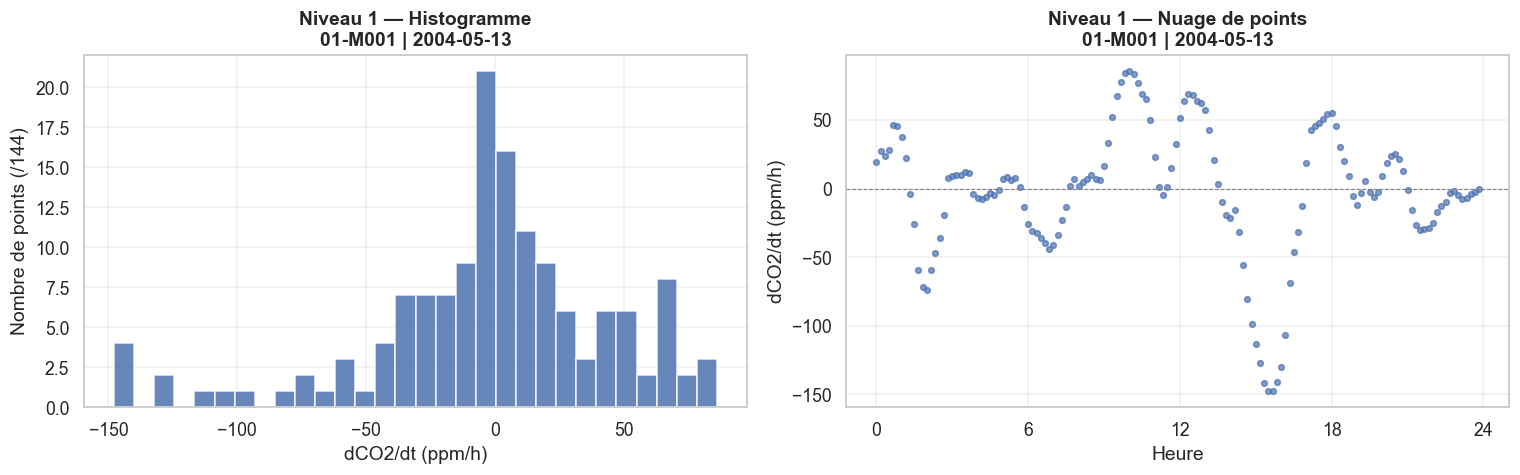

Amplitude : [-148, 86] ppm/h — écart-type 47


In [ ]:
# ── Niveau 1 : une journée, un logement — dérivée brute, aucune normalisation
idx1 = 0
code1, date1 = meta.loc[idx1, 'CODELIEU'], meta.loc[idx1, 'DATE']
vals1 = deriv_brute[idx1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(vals1, bins=30, color='#4C72B0', alpha=0.85)
axes[0].set_title(f'Niveau 1 — Histogramme\n{code1} | {date1.date()}', fontweight='bold')
axes[0].set_xlabel('dCO2/dt (ppm/h)'); axes[0].set_ylabel('Nombre de points (/144)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(hours, vals1, s=14, color='#4C72B0', alpha=0.7)
axes[1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1].set_title(f'Niveau 1 — Nuage de points\n{code1} | {date1.date()}', fontweight='bold')
axes[1].set_xlabel('Heure'); axes[1].set_ylabel('dCO2/dt (ppm/h)')
axes[1].set_xticks([0, 6, 12, 18, 24]); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Amplitude : [{vals1.min():.0f}, {vals1.max():.0f}] ppm/h — écart-type {vals1.std():.0f}')


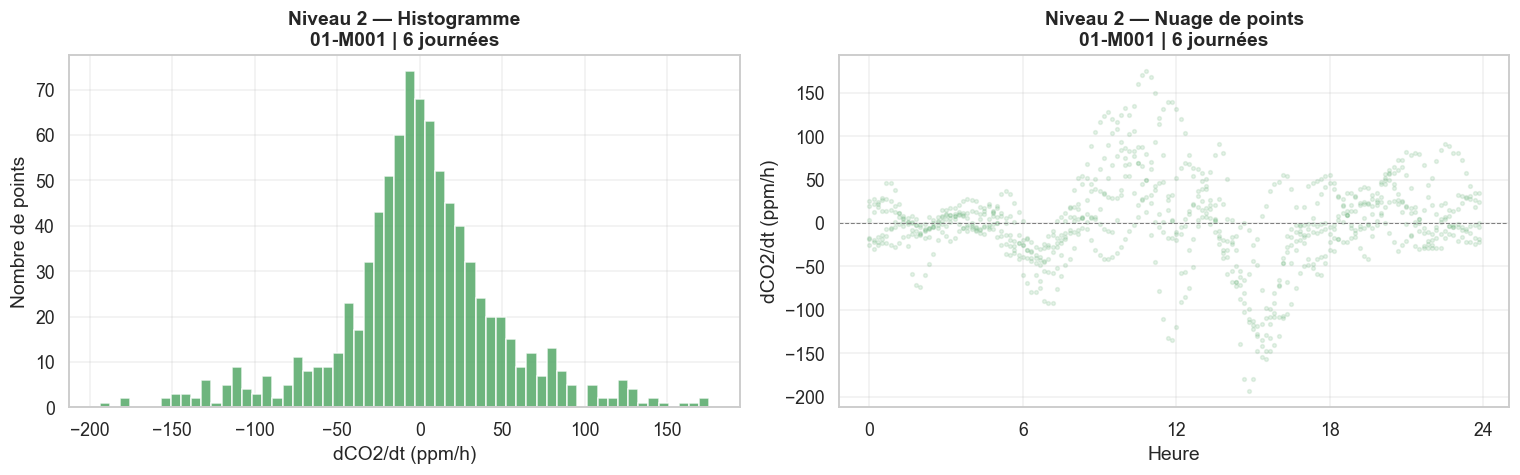

Amplitude : [-194, 176] ppm/h — écart-type 50


In [ ]:
# ── Niveau 2 : toutes les journées d'un même logement — dérivée brute
sel2 = (meta['CODELIEU'] == code1).to_numpy()
vals2_2d = deriv_brute[sel2]
vals2 = vals2_2d.ravel()
hours2 = np.tile(hours, vals2_2d.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(vals2, bins=60, color='#55A868', alpha=0.85)
axes[0].set_title(f'Niveau 2 — Histogramme\n{code1} | {sel2.sum()} journées', fontweight='bold')
axes[0].set_xlabel('dCO2/dt (ppm/h)'); axes[0].set_ylabel('Nombre de points')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(hours2, vals2, s=6, color='#55A868', alpha=0.15)
axes[1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1].set_title(f'Niveau 2 — Nuage de points\n{code1} | {sel2.sum()} journées', fontweight='bold')
axes[1].set_xlabel('Heure'); axes[1].set_ylabel('dCO2/dt (ppm/h)')
axes[1].set_xticks([0, 6, 12, 18, 24]); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Amplitude : [{vals2.min():.0f}, {vals2.max():.0f}] ppm/h — écart-type {vals2.std():.0f}')


Date retenue : 2004-03-14 — 16 logements simultanés


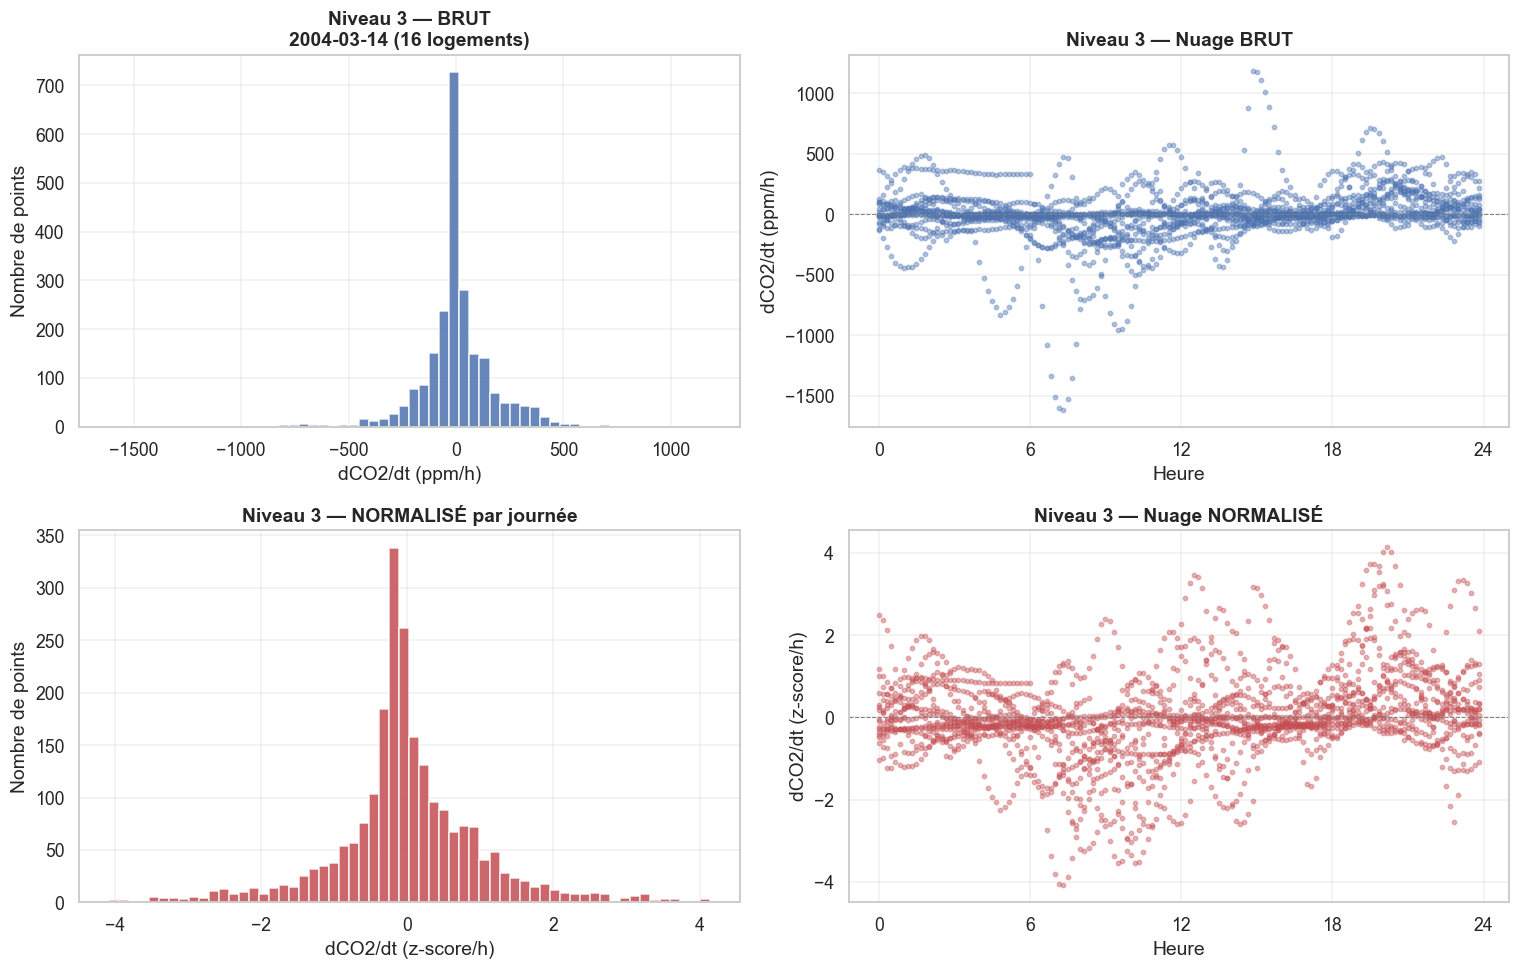

Brut : [-1614, 1181] ppm/h  →  normalisé : [-4.1, 4.1] z-score


In [ ]:
# ── Niveau 3 : plusieurs logements, une même journée
# Les logements ne sont pas mesurés aux mêmes dates (campagnes tournantes d'environ
# une semaine) : on retient la date où le plus de logements sont mesurés simultanément.
n_logs_par_date = meta.groupby('DATE')['CODELIEU'].nunique()
best_date = n_logs_par_date.idxmax()
sel3 = np.where((meta['DATE'] == best_date).to_numpy())[0]
print(f'Date retenue : {best_date.date()} — {n_logs_par_date.max()} logements simultanés')

vals3_raw_2d = deriv_brute[sel3]
vals3_raw = vals3_raw_2d.ravel()
hours3 = np.tile(hours, vals3_raw_2d.shape[0])

# Version normalisée : chaque journée ramenée à sa propre moyenne / écart-type
mu3, sig3 = vals3_raw_2d.mean(axis=1, keepdims=True), vals3_raw_2d.std(axis=1, keepdims=True)
vals3_norm = ((vals3_raw_2d - mu3) / np.clip(sig3, 1e-9, None)).ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(vals3_raw, bins=60, color='#4C72B0', alpha=0.85)
axes[0, 0].set_title(f'Niveau 3 — BRUT\n{best_date.date()} ({len(sel3)} logements)', fontweight='bold')
axes[0, 0].set_xlabel('dCO2/dt (ppm/h)'); axes[0, 0].set_ylabel('Nombre de points')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(hours3, vals3_raw, s=8, color='#4C72B0', alpha=0.4)
axes[0, 1].axhline(0, color='grey', lw=0.7, ls='--')
axes[0, 1].set_title('Niveau 3 — Nuage BRUT', fontweight='bold')
axes[0, 1].set_xlabel('Heure'); axes[0, 1].set_ylabel('dCO2/dt (ppm/h)')
axes[0, 1].set_xticks([0, 6, 12, 18, 24]); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(vals3_norm, bins=60, color='#C44E52', alpha=0.85)
axes[1, 0].set_title('Niveau 3 — NORMALISÉ par journée', fontweight='bold')
axes[1, 0].set_xlabel('dCO2/dt (z-score/h)'); axes[1, 0].set_ylabel('Nombre de points')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(hours3, vals3_norm, s=8, color='#C44E52', alpha=0.4)
axes[1, 1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1, 1].set_title('Niveau 3 — Nuage NORMALISÉ', fontweight='bold')
axes[1, 1].set_xlabel('Heure'); axes[1, 1].set_ylabel('dCO2/dt (z-score/h)')
axes[1, 1].set_xticks([0, 6, 12, 18, 24]); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Brut : [{vals3_raw.min():.0f}, {vals3_raw.max():.0f}] ppm/h  →  '
      f'normalisé : [{vals3_norm.min():.1f}, {vals3_norm.max():.1f}] z-score')


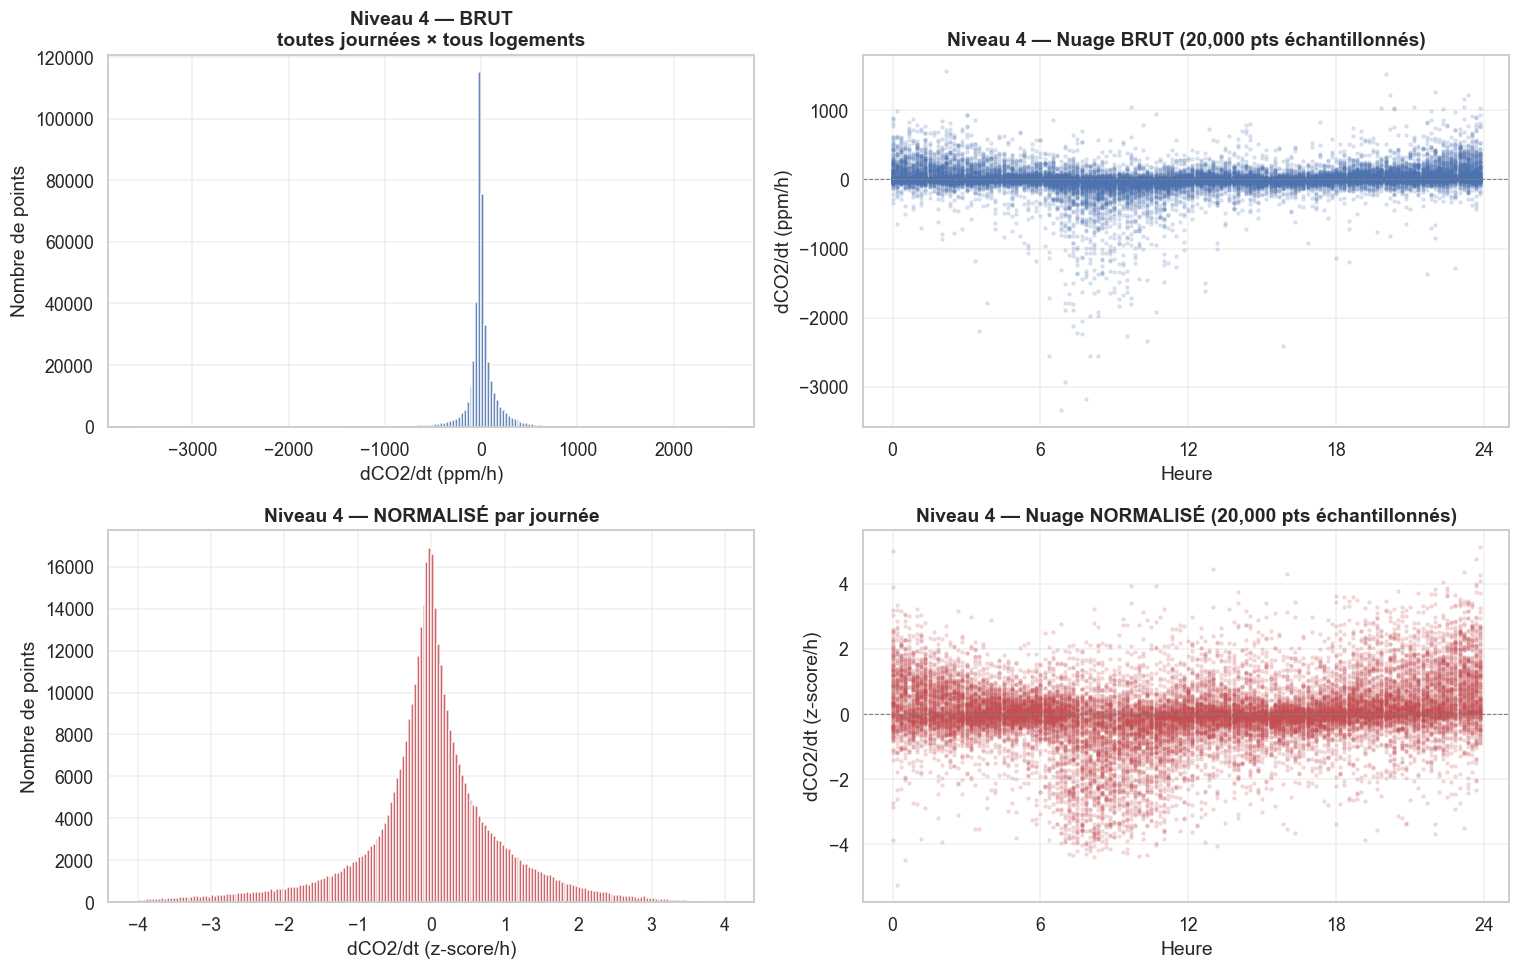

Brut : [-3568, 2534] ppm/h  →  normalisé : [-8.0, 8.3] z-score


In [ ]:
# ── Niveau 4 : toutes les journées × tous les logements
vals4_raw = deriv_brute.ravel()
mu4, sig4 = deriv_brute.mean(axis=1, keepdims=True), deriv_brute.std(axis=1, keepdims=True)
vals4_norm = ((deriv_brute - mu4) / np.clip(sig4, 1e-9, None)).ravel()

# Le nuage est sous-échantillonné pour rester lisible ; les histogrammes utilisent tout.
SUBSAMPLE = 20_000
rng = np.random.RandomState(42)
sub = rng.choice(len(vals4_raw), min(SUBSAMPLE, len(vals4_raw)), replace=False)
hours4 = np.tile(hours, deriv_brute.shape[0])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(vals4_raw, bins=200, color='#4C72B0', alpha=0.85)
axes[0, 0].set_title('Niveau 4 — BRUT\ntoutes journées × tous logements', fontweight='bold')
axes[0, 0].set_xlabel('dCO2/dt (ppm/h)'); axes[0, 0].set_ylabel('Nombre de points')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(hours4[sub], vals4_raw[sub], s=4, color='#4C72B0', alpha=0.15)
axes[0, 1].axhline(0, color='grey', lw=0.7, ls='--')
axes[0, 1].set_title(f'Niveau 4 — Nuage BRUT ({SUBSAMPLE:,} pts échantillonnés)', fontweight='bold')
axes[0, 1].set_xlabel('Heure'); axes[0, 1].set_ylabel('dCO2/dt (ppm/h)')
axes[0, 1].set_xticks([0, 6, 12, 18, 24]); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(vals4_norm, bins=200, range=(-4, 4), color='#C44E52', alpha=0.85)
axes[1, 0].set_title('Niveau 4 — NORMALISÉ par journée', fontweight='bold')
axes[1, 0].set_xlabel('dCO2/dt (z-score/h)'); axes[1, 0].set_ylabel('Nombre de points')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(hours4[sub], vals4_norm[sub], s=4, color='#C44E52', alpha=0.15)
axes[1, 1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1, 1].set_title(f'Niveau 4 — Nuage NORMALISÉ ({SUBSAMPLE:,} pts échantillonnés)', fontweight='bold')
axes[1, 1].set_xlabel('Heure'); axes[1, 1].set_ylabel('dCO2/dt (z-score/h)')
axes[1, 1].set_xticks([0, 6, 12, 18, 24]); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Brut : [{vals4_raw.min():.0f}, {vals4_raw.max():.0f}] ppm/h  →  '
      f'normalisé : [{vals4_norm.min():.1f}, {vals4_norm.max():.1f}] z-score')


### Conclusion — normalisation par journée

Les niveaux 1 et 2 montrent qu'un **même logement reste comparable à lui-même**
d'un jour à l'autre : même ordre de grandeur, motif journalier reconnaissable.

Le passage au niveau 3 change radicalement d'échelle : en ajoutant seulement
d'autres **logements** (sans ajouter de jours), l'amplitude est multipliée par
un ordre de grandeur. Quelques logements à forte variabilité écrasent alors
tous les autres — un seuil exprimé en ppm/h n'a plus le même sens d'un
logement à l'autre.

**Retenu pour la suite** : chaque journée est normalisée par sa propre moyenne
et son propre écart-type (z-score par journée). Ce choix efface le niveau et
l'amplitude absolus pour ne conserver que la **forme** de la journée, ce qui
est précisément l'objet du clustering.


In [ ]:
# Normalisation retenue : z-score par journée, appliqué à la dérivée
mu_day  = deriv_brute.mean(axis=1, keepdims=True)
sig_day = deriv_brute.std(axis=1, keepdims=True)
D = (deriv_brute - mu_day) / np.clip(sig_day, 1e-9, None)

print(f'D : {D.shape} — dérivée normalisée par journée')
print('Contrôle (3 premières journées) — moyenne :', D.mean(axis=1)[:3].round(3),
      '| écart-type :', D.std(axis=1)[:3].round(3))


D : (2998, 144) — dérivée normalisée par journée
Contrôle (3 premières journées) — moyenne : [-0. -0.  0.] | écart-type : [1. 1. 1.]


## 4. Clustering DTW des journées

Le **DTW** (*Dynamic Time Warping*) compare deux séries en autorisant un léger
décalage temporel : deux journées présentant le même enchaînement d'événements
décalé de quelques dizaines de minutes sont reconnues comme proches, là où une
distance euclidienne les jugerait très différentes.

La contrainte de Sakoe-Chiba (rayon 6 pas de 10 min, soit ±1h) borne ce
réalignement : au-delà, un événement du matin pourrait être apparié à un
événement du soir, ce qui n'aurait pas de sens ici.


In [ ]:
# Choix de K — méthode du coude sur un sous-échantillon (le DTW est coûteux :
# 13 valeurs de k × un clustering complet chacune). La forme de la courbe
# suffit à localiser le coude ; le clustering final portera sur tout le jeu.
SUBSAMPLE_K = 800
rng_k = np.random.RandomState(0)
sub_k = rng_k.choice(len(D), min(SUBSAMPLE_K, len(D)), replace=False)

ks, inerties = range(2, 15), []
for k in ks:
    km = TimeSeriesKMeans(n_clusters=k, metric='dtw',
                          metric_params={'global_constraint': 'sakoe_chiba',
                                         'sakoe_chiba_radius': 6},
                          random_state=42, n_jobs=-1)
    km.fit(D[sub_k][:, :, None])
    inerties.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(ks), inerties, marker='o')
ax.set_xlabel('Nombre de clusters k'); ax.set_ylabel('Inertie DTW')
ax.set_title('Méthode du coude — DTW sur dérivée normalisée par journée', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# K retenu au vu du coude ci-dessus : la baisse d'inertie ralentit nettement
# au-delà de 5 clusters.
K = 5

model = TimeSeriesKMeans(
    n_clusters=K, metric='dtw',
    metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
    random_state=42, n_jobs=-1, verbose=0,
)
labels = model.fit_predict(D[:, :, None])
meta['cluster'] = labels

print(f'K = {K}')
print('Effectifs par cluster :')
print(pd.Series(labels).value_counts().sort_index().to_string())


In [ ]:
# Profil de chaque cluster : barycentre DTW (réaligné) + moyenne ± écart-type
n_cols = min(K, 3)
n_rows = int(np.ceil(K / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.8 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
we_global = meta['we'].mean() * 100

for c in range(K):
    ax = axes[c]
    sel = labels == c
    m, s = D[sel].mean(axis=0), D[sel].std(axis=0)

    ax.fill_between(hours, m - s, m + s, alpha=0.15, color='#4C72B0', label='moyenne ± σ')
    ax.plot(hours, model.cluster_centers_[c].ravel(), lw=2, color='#C44E52',
            label='barycentre DTW')
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.set_title(f'Cluster {c} — n={sel.sum():,} '
                 f'({meta.loc[sel, "we"].mean()*100:.0f}% week-end)',
                 fontsize=10, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24]); ax.grid(True, alpha=0.25)
    if c == 0:
        ax.legend(fontsize=8, loc='upper right')

for ax in axes[K:]:
    ax.axis('off')

fig.supxlabel('Heure'); fig.supylabel('dCO2/dt normalisée par journée')
plt.suptitle(f'Profils des {K} clusters (part de week-end sur l\'ensemble : {we_global:.0f}%)',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


In [ ]:
# Journées réelles de chaque cluster : CO2 brut, CO2 normalisé, dérivée normalisée
EX = pd.concat([d.sample(min(2, len(d)), random_state=42)
                for _, d in meta.groupby('cluster')])
print('Journées affichées (2 tirées au hasard par cluster) :')
print(EX[['CODELIEU', 'DATE', 'cluster']].to_string(index=False))

mu_c, sig_c = co2_brut.mean(axis=1, keepdims=True), co2_brut.std(axis=1, keepdims=True)
co2_norm = (co2_brut - mu_c) / np.clip(sig_c, 1e-9, None)

PANELS = [('CO2 brut (ppm)', co2_brut, False),
          ('CO2 normalisé\npar journée', co2_norm, True),
          ('dCO2/dt normalisée\npar journée', D, True)]
colors = ['#4C72B0', '#C44E52']

fig, axes = plt.subplots(len(PANELS), K, figsize=(4 * K, 3 * len(PANELS)), sharex=True)

for c in range(K):
    sub_ex = EX[EX['cluster'] == c]
    for row, (ylabel, arr, zeroline) in enumerate(PANELS):
        ax = axes[row, c]
        for (idx, r), color in zip(sub_ex.iterrows(), colors):
            ax.plot(hours, arr[idx], lw=1.4, color=color,
                    label=f"{r['CODELIEU']} | {r['DATE'].date()}")
        if zeroline:
            ax.axhline(0, color='grey', lw=0.7, ls='--')
        ax.set_xticks([0, 6, 12, 18, 24]); ax.grid(True, alpha=0.25)
        if row == 0:
            ax.set_title(f'Cluster {c}', fontsize=10, fontweight='bold')
            ax.legend(fontsize=6.5, loc='upper right')
        if c == 0:
            ax.set_ylabel(ylabel)

fig.supxlabel('Heure')
plt.suptitle('Deux journées réelles par cluster', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## 5. Caractérisation des clusters

Deux niveaux de lecture :
- **par journée** : chaque journée porte son cluster ;
- **par logement** : on retient le cluster **dominant** de ses journées, ce qui
  évite qu'un logement observé longtemps ne pèse plusieurs fois dans les
  statistiques croisées.


In [ ]:
# Validation par une variable indépendante du signal : le type de ventilation
val = meta.copy()
val['aeration'] = val['CODELIEU'].map(ventilation)

ct = pd.crosstab(val['cluster'], val['aeration'], normalize='index').mul(100).round(1)
display(ct.style.background_gradient(cmap='YlOrRd', axis=None).format('{:.1f}%')
        .set_caption("Type de ventilation par cluster (% des journées)"))

# Cluster dominant par logement — base des croisements suivants
log_dom = val.groupby('CODELIEU')['cluster'].agg(lambda x: x.value_counts().idxmax())
log_aer = val.groupby('CODELIEU')['aeration'].first()

ct_log = pd.crosstab(log_dom, log_aer, normalize='index').mul(100).round(1)
display(ct_log.style.background_gradient(cmap='YlOrRd', axis=None).format('{:.1f}%')
        .set_caption("Type de ventilation par cluster dominant (1 ligne = 1 logement)"))

print(f'{len(log_dom)} logements rattachés à un cluster dominant')


In [ ]:
# Caractéristiques du logement et du ménage
FC3_LABELS = {
    1: 'Maison individuelle', 2: 'Appart. (collectif)', 3: 'Studio (collectif)',
    4: 'Pièce indépendante', 5: 'Logement-foyer', 6: 'Ferme / bât. agricole',
    7: 'Chambre hôtel', 8: 'Construction provisoire', 9: 'Immeuble à usage pro',
}
STRMEN_LABELS = {1: 'Personne seule', 2: 'Famille monoparentale',
                 3: 'Couple', 4: 'Autre ménage'}
INDT_LABELS = {'1': 'Travaille', '2': 'Étudiant', '3': 'Ne travaille pas'}

q_men = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                    sep=';', encoding='latin1',
                    usecols=['CODELIEU', 'FC3', 'STRMEN', 'HSRF', 'NPP']).set_index('CODELIEU')
q_men['type_logement']    = pd.to_numeric(q_men['FC3'], errors='coerce').map(FC3_LABELS)
q_men['structure_menage'] = pd.to_numeric(q_men['STRMEN'], errors='coerce').map(STRMEN_LABELS)
q_men['surface']          = pd.to_numeric(q_men['HSRF'], errors='coerce')
q_men['nb_pieces']        = pd.to_numeric(q_men['NPP'], errors='coerce')

q_ind = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_INDIVIDU_DATA.csv',
                    sep=';', encoding='latin1',
                    usecols=['CODELIEU', 'NUM_OCCUPANT', 'INDT'], dtype={'INDT': str})
q_ind['statut_pro'] = q_ind['INDT'].map(INDT_LABELS).fillna('Non renseigné / enfant')
q_ind['cluster'] = q_ind['CODELIEU'].map(log_dom)

car = pd.DataFrame({'cluster': log_dom}).join(
    q_men[['type_logement', 'structure_menage', 'surface', 'nb_pieces']])
car['nb_occupants'] = car.index.map(q_ind.groupby('CODELIEU')['NUM_OCCUPANT'].nunique())
car['au_moins_un_actif'] = car.index.map(
    q_ind.groupby('CODELIEU')['INDT'].apply(lambda s: (s == '1').any()))

print(f"{len(car)} logements — {car['surface'].notna().sum()} avec surface renseignée, "
      f"{car['type_logement'].notna().sum()} avec type de logement, "
      f"{q_ind['cluster'].notna().sum()}/{len(q_ind)} occupants rattachés")


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

ax = axes[0, 0]
sns.boxplot(data=car.dropna(subset=['surface']), x='cluster', y='surface',
           hue='cluster', palette='Set2', legend=False, ax=ax)
ax.set_title('Surface du logement (m²)', fontweight='bold')
ax.set_xlabel('Cluster dominant'); ax.set_ylabel('Surface (m²)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[0, 1]
sns.boxplot(data=car.dropna(subset=['nb_occupants']), x='cluster', y='nb_occupants',
           hue='cluster', palette='Set2', legend=False, ax=ax)
ax.set_title("Nombre d'occupants", fontweight='bold')
ax.set_xlabel('Cluster dominant'); ax.set_ylabel("Nb d'occupants")
ax.grid(True, axis='y', alpha=0.3)

ax = axes[0, 2]
sns.heatmap(pd.crosstab(car['cluster'], car['type_logement'], normalize='index').mul(100),
           annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '%'})
ax.set_title('Type de logement (%)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Cluster dominant')

ax = axes[1, 0]
sns.heatmap(pd.crosstab(car['cluster'], car['structure_menage'], normalize='index').mul(100),
           annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '%'})
ax.set_title('Structure du ménage (%)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Cluster dominant')

ax = axes[1, 1]
ct_statut = pd.crosstab(q_ind['cluster'], q_ind['statut_pro'], normalize='index').mul(100)
ordre = [c for c in ['Travaille', 'Étudiant', 'Ne travaille pas', 'Non renseigné / enfant']
        if c in ct_statut.columns]
sns.heatmap(ct_statut[ordre], annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
           cbar_kws={'label': '%'})
ax.set_title('Statut professionnel des occupants (%)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Cluster dominant')

axes[1, 2].axis('off')
plt.suptitle('Profil des logements par cluster dominant', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

recap = car.groupby('cluster').agg(
    n_logements=('surface', 'size'),
    surface_mediane=('surface', 'median'),
    nb_pieces_median=('nb_pieces', 'median'),
    nb_occupants_median=('nb_occupants', 'median'),
    pct_avec_actif=('au_moins_un_actif', lambda s: 100 * s.mean()),
)
display(recap.round(1))


## 6. Synthèse

À compléter après lecture des résultats : décrire chaque cluster en une phrase
(forme de la journée + profil d'occupants associé), puis indiquer les clusters
qui se distinguent nettement des autres et ceux qui restent ambigus.
